In [39]:
import argparse
import datetime
import dateutil
import email
import glob
import inspect
import itertools
import json
import openai
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import pickle
import random
import re
import requests
import sys
import time


from ast import literal_eval
from collections import OrderedDict
from tenacity import (
    retry,
    stop_after_attempt,
    wait_random_exponential,
)

In [2]:
def thread_to_string(thread):
  s=""
  for e in thread:
    s += f"{e}"
  return s

def random_thread(emails):
  random_key, random_value = random.choice(list(emails.items()))
  return random_value

In [3]:
# the pipermail download tool has a specific naming convention for the downloaded files.
# use that convention to sort them by time
def get_sorted_filenames(archive):    
    filename_pattern = f"{archive}/[1-9][0-9][0-9][0-9]-[A-Z][a-z]*.txt"
    matching_files = glob.glob(filename_pattern)

    def piper_sort(filename):
        match = re.search(r'(\d{4})-(\w+).txt', filename)
        if match:
            year, month = match.groups()
            month_order = [
                'January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December'
            ]
            return int(year), month_order.index(month)
        else:
          print(f"Error: Attempting to analyze a file {filename} which does not appear to hold pipermail")
          sys.exit(255)
    
    return sorted(matching_files, key=piper_sort)

# separate the parsing of the file from the processing of the emails.
# just parse the file here and return an array of emails
def file_to_emails(filename):
    delimiter_pattern = r'From +([\w\.\-\+]+) +at +([\w\.\-]+) +([\w\s\d:]+)'
    
    # read the file a line at a time and start a new email whenever we see the delimiter
    email_strings = [ ]
    with open(filename, "r") as f:
        for line in f:
            delimiter = re.search(delimiter_pattern,line)
            if delimiter:
                email_strings.append(line) # start a new email
            else:
                email_strings[-1] += line  # just append to existing email
                
    return email_strings

# if we find an email with a reply-to flag, it might be replying the first email in a thread or another reply.
# recurse so we always group emails together with the first email in a thread
def find_original_email(msg,all_msgs):
    mid = msg.get('Message-ID')
    rep = msg.get('In-Reply-To')
    if not rep:
        return (mid,False)
    else:
        try:
            return find_original_email(all_msgs[rep],all_msgs)
        except KeyError:
            print(f"WARN: Orphaned email {rep}.")
            return (rep,True)

def Debug(msg):
    print(msg)
    
def get_all_emails(archive):
    all_emails = OrderedDict()
    
    for filename in get_sorted_filenames(archive):
        print(filename)
        email_strings = file_to_emails(filename)
        for email_string in email_strings:
            # all the fields available: ['From', 'Date', 'Subject', 'In-Reply-To', 'References', 'Message-ID']
            msg = email.message_from_string(email_string)
            all_emails[msg.get('Message-ID')] = msg
    
    return all_emails

In [4]:
# helper routine to help debug the parsing and grouping of emails into threads
def debug_message_id(mid):
    group = None
    if mid in discuss_emails:
        msg = discuss_emails[mid]
        group = 'Discuss'
    elif mid in devel_emails:
        msg = devel_emails[mid]
        group = 'Devel'
    elif mid in absentees:
        msg = absentees[mid]
        group = 'Absentee'
    else:
        print(f"Unknown mid {mid}")
        return None
    msg['Group'] = group
    print(msg.items())
# debug_message_id('<4726C49C.60800@sun.com>')

In [5]:
# return pid of parent, True/False for whether the child is an orphan (i.e. parent is missing)
# returns None, False if no parent and it wasn't expecting to find one
# returns pid, True if there should be a parent but it's missing
def find_parent(msg,all_subjects,all_emails,email_threads):
    # try to match subject
    sub = msg.get('Subject')
    if sub and sub in all_subjects:
        return all_subjects[sub], False
    
    # then try to match any references
    ref = msg.get('References')
    try:
        for r in ref.split():
            if r in email_threads:
                return r, False
    except AttributeError:
        pass # there was no ref
    
    # then try to match any reply-to
    rep = msg.get('In-Reply-To')
    if rep:
        while rep:
            if rep in email_threads:
                return rep, False
            else:
                # keep looking backwards until we find an email starting
                try:
                    rep = all_emails[rep].get('In-Reply-To')
                except KeyError:
                    #print(f"Orphan found. {rep} is missing parent.")
                    #absentee_parents[rep] = absentee_parents.get(rep, 0) + 1
                    return rep,True
    return None, False

def emails_to_threads(all_emails):
    all_subjects = {}             # to find parents
    email_threads = OrderedDict() # to return them
    for msg in all_emails.values():
        sub = msg.get('Subject')
        mid = msg.get('Message-ID')
        ref = msg.get('References')
        rep = msg.get('In-Reply-To')
        
        def new_thread(mid,msg,sub):
            email_threads[mid] = [msg,]
            all_subjects[sub] = mid
            
        def append_thread(msg,pid):
            email_threads[pid].append(msg)
        
        # is it a new thread?
        if not ref and not rep and sub not in all_subjects:
            new_thread(mid,msg,sub)
            continue
        
        # else try to find the parent
        pid,orphan = find_parent(msg,all_subjects,all_emails,email_threads)
        if orphan:
            new_thread(pid,msg,sub) # create a new thread but identify it by ID of missing parent
            absentees[pid]=msg
        elif pid:
            append_thread(msg,pid)
        else:
            new_thread(mid,msg,sub)
            
    print(f"Collapsed {len(all_emails)} emails into {len(email_threads)} threads.")
    return email_threads
            


In [6]:
# a global dict to help with debugging
absentees = {}
if True: # we already fetched them, whoops, we threw them away. Should probably pickle these also
    discuss_emails = get_all_emails('lustre-discuss')
    discuss_threads = emails_to_threads(discuss_emails)
    devel_emails = get_all_emails('lustre-devel')
    devel_threads = emails_to_threads(devel_emails)

lustre-discuss/2007-September.txt
lustre-discuss/2007-October.txt
lustre-discuss/2007-November.txt
lustre-discuss/2007-December.txt
lustre-discuss/2008-January.txt
lustre-discuss/2008-February.txt
lustre-discuss/2008-March.txt
lustre-discuss/2008-April.txt
lustre-discuss/2008-May.txt
lustre-discuss/2008-June.txt
lustre-discuss/2008-July.txt
lustre-discuss/2008-August.txt
lustre-discuss/2008-September.txt
lustre-discuss/2008-October.txt
lustre-discuss/2008-November.txt
lustre-discuss/2008-December.txt
lustre-discuss/2009-January.txt
lustre-discuss/2009-February.txt
lustre-discuss/2009-March.txt
lustre-discuss/2009-April.txt
lustre-discuss/2009-May.txt
lustre-discuss/2009-June.txt
lustre-discuss/2009-July.txt
lustre-discuss/2009-August.txt
lustre-discuss/2009-September.txt
lustre-discuss/2009-October.txt
lustre-discuss/2009-November.txt
lustre-discuss/2009-December.txt
lustre-discuss/2010-January.txt
lustre-discuss/2010-February.txt
lustre-discuss/2010-March.txt
lustre-discuss/2010-April

lustre-devel/2015-November.txt
lustre-devel/2015-December.txt
lustre-devel/2016-January.txt
lustre-devel/2016-February.txt
lustre-devel/2016-March.txt
lustre-devel/2016-April.txt
lustre-devel/2016-May.txt
lustre-devel/2016-June.txt
lustre-devel/2016-July.txt
lustre-devel/2016-August.txt
lustre-devel/2016-September.txt
lustre-devel/2016-October.txt
lustre-devel/2016-November.txt
lustre-devel/2016-December.txt
lustre-devel/2017-January.txt
lustre-devel/2017-February.txt
lustre-devel/2017-March.txt
lustre-devel/2017-April.txt
lustre-devel/2017-May.txt
lustre-devel/2017-June.txt
lustre-devel/2017-July.txt
lustre-devel/2017-August.txt
lustre-devel/2017-September.txt
lustre-devel/2017-October.txt
lustre-devel/2017-November.txt
lustre-devel/2017-December.txt
lustre-devel/2018-January.txt
lustre-devel/2018-February.txt
lustre-devel/2018-March.txt
lustre-devel/2018-April.txt
lustre-devel/2018-May.txt
lustre-devel/2018-June.txt
lustre-devel/2018-July.txt
lustre-devel/2018-August.txt
lustre-devel

In [7]:
instructions = "You will be provided an email thread about lustre. Please respond in JSON with these fields. Summary: concise summary. Category: Single-word classification. Topic: Another single-word classificationTone: single-word classification of the emotional tone. Answered: true or false whether any initial question was answered. For category, please try to use one of the following words but use a different one if none of these are a good fit: compilation, bug, stability, feature_request, performance, installation, configuration, announcement, patch, architecture, deployment."

def query_chatgpt(thread,model):
    thread_string = '\n'.join([f"{msg}" for msg in thread])
    
    openai.api_key = os.getenv("OPENAI_API_KEY")
    
    @retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
    def completion_with_backoff(**kwargs):
        print("Attempting chat gpt query on {this_mid}")
        return openai.ChatCompletion.create(**kwargs)
    
    # for debugging
    this_mid = thread[0].get('Message-ID')
    #response = openai.ChatCompletion.create(
    response = completion_with_backoff(
        model=model,
        messages=[
          {
            "role": "system",
            "content": instructions         
          },
          {
            "role": "user",
            "content": thread_string
          }
        ],
        temperature=0.5,
        max_tokens=256,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0
    )

    return response

def query_chatgpt2(thread,model):
    api_key = os.getenv("OPENAI_API_KEY")
    headers = {"Authorization": f"Bearer {api_key}"}
    thread_string = '\n'.join([f"{msg}" for msg in thread])
    
    data = {
        "model": model,
        "messages": [
            {
                "role": "system",
                "content": instructions
            },
            {
                "role": "user",
                "content": thread_string
            }
        ]
    }
    
    # hitting rate limits. Add exponential backoff.
    @retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
    def completion_with_backoff(**kwargs):
        print("Attempting completion with backoff")
        return requests.post(**kwargs)
            
    response = completion_with_backoff(url="https://api.openai.com/v1/chat/completions", headers=headers, json=data)

    rate_limit_info = {
        "Rate Limit - Requests": response.headers.get('x-ratelimit-limit-requests'),
        "Rate Limit - Tokens": response.headers.get('x-ratelimit-limit-tokens'),
        "Remaining - Requests": response.headers.get('x-ratelimit-remaining-requests'),
        "Remaining - Tokens": response.headers.get('x-ratelimit-remaining-tokens'),
        "Reset Time - Requests": response.headers.get('x-ratelimit-reset-requests'),
        "Reset Time - Tokens": response.headers.get('x-ratelimit-reset-tokens')
    }
    if response.status_code == 200:        
        print(rate_limit_info)
        #print(response.json())
        return response.json(), response.status_code
    else:
        print(f"Failed to get response. Status code: {response.status_code}")
        print(f"{response.headers}")
        print(f"{response.json()}")
        return response.json(), response.status_code

In [8]:
analysis_pickle = 'analysis_pickle.pkl'
failure_pickle = 'failure_pickle.pkl'
try:
    with open(analysis_pickle, 'rb') as f:
        analyzed_threads = pickle.load(f)
except FileNotFoundError:
    analyzed_threads = {}
#print(analyzed_threads)

# start storing the failed_threads also. Need to pickle this as well.
try: 
    with open(failure_pickle, 'rb') as f:
        failed_threads = pickle.load(f)
except FileNotFoundError:
    failed_threads = {}
print(f"Have analyzed {len(analyzed_threads)} out of {len(discuss_threads)+len(devel_threads)}. {len(failed_threads)} failed threads.")

Have analyzed 3357 out of 7083. 857 failed threads.


In [9]:
def analyze_thread(thread):
    if not hasattr(analyze_thread, "_initial_delay"):
        analyze_thread._initial_delay = 5
    if not hasattr(analyze_thread, "_delay"):
        print("setting initial delay value")
        analyze_thread._delay = 5
    mid = thread[0].get('Message-ID')
    ret = None
    model = "gpt-4"
    #model = 'gpt-3.5-turbo'
    if mid not in analyzed_threads and mid not in failed_threads:
        try:
            response,status_code = query_chatgpt2(thread,model)
            ret = response
            if response and status_code == 200:   
                js = json.loads(response['choices'][0]['message']['content'])
                print(json.dumps(js, indent=4))
                analyzed_threads[mid] = response
                with open(analysis_pickle, 'wb') as f:
                    pickle.dump(analyzed_threads, f)
                analyze_thread._delay = analyze_thread._initial_delay # reset exponential backoff
            else:
                if response and status_code == 429:
                    print(f"Hit rate limit {status_code}, will wait {analyze_thread._delay} seconds before trying again")
                else:
                    print(f"Unknown error {status_code}, will wait {analyze_thread._delay} seconds before trying again")
                time.sleep(analyze_thread._delay)
                analyze_thread._delay = min(60,analyze_thread._delay * 2)
                failed_threads[mid] = (response,status_code)
                with open(failure_pickle, 'wb') as f:
                    pickle.dump(failed_threads, f)
        except Exception as e:
            print(f"Exception {e}")
            analyze_thread._delay = min(60,analyze_thread._delay * 2)
            print(f"will wait {analyze_thread._delay} seconds before trying again")
            time.sleep(analyze_thread._delay)
            #failed_threads[mid] = e # these ones are causing problems. Don't save them.
            with open(failure_pickle, 'wb') as f:
                pickle.dump(failed_threads, f)
            ret = None
    else:
        if mid in analyzed_threads:
            print(f"Cowardly refusing to analyze already analyzed thread {mid}.")
        else:
            print(f"Cowardly refusing to analyze already failed thread {mid}.")
        ret = None
    return ret

In [10]:
# test the analyze_thread code
thread = random_thread(discuss_threads)
response = analyze_thread(thread)

setting initial delay value
Attempting completion with backoff
{'Rate Limit - Requests': '5000', 'Rate Limit - Tokens': '80000', 'Remaining - Requests': '4999', 'Remaining - Tokens': '79727', 'Reset Time - Requests': '12ms', 'Reset Time - Tokens': '204ms'}
{
    "Summary": "Troy Benjegerdes is inquiring about how to force traffic over o2ib instead of TCP in an existing filesystem. The filesystem was initially created with the MGS listing just the TCP address.",
    "Category": "configuration",
    "Topic": "networking",
    "Tone": "inquisitive",
    "Answered": false
}


In [11]:
# process both lists. We later want to analyze them separately but just collect all of them now
# to separate later, just search for the analysis key as a message id in both of the threads dict
# I'm seeing too many API errors. Reverse the threads in case there is some other issue.
# Shuffle the discuss_threads
shuffled_discuss_threads = list(discuss_threads.values())
random.shuffle(shuffled_discuss_threads)
print("Currently disabling doing additional analysis")
#for thread in itertools.chain(shuffled_discuss_threads, devel_threads.values()):
#    analyze_thread(thread)

Currently disabling doing additional analysis


In [12]:
# clear the exponential delay without resetting entire notebook
if hasattr(analyze_thread, "_delay"):
    delattr(analyze_thread, "_delay")


In [13]:
#failed_threads
with open(failure_pickle, 'wb') as f:
    pickle.dump(failed_threads, f)
#del(failed_threads['<4C73F4D2.7030702@diamond.ac.uk>'])

In [14]:
print(f"Have analyzed {len(analyzed_threads)} out of {len(discuss_threads)+len(devel_threads)}. {len(failed_threads)} failed threads.")

Have analyzed 3358 out of 7083. 857 failed threads.


In [15]:
discuss=0
devel=0
unknowns=0
for tid,t in analyzed_threads.items():
    # at some point, we want to filter across discuss threads and devel threads
    # right now however all are in discuss so no need to do anything differently
    if tid in discuss_emails:
        discuss+=1        
    elif tid in devel_emails:
        devel+=1
    else:
        print(f"Unknown thread {tid} somehow analyzed?")
        #debug_message_id(tid)
        unknowns+=1
print(discuss,devel,unknowns)


3358 0 0


In [61]:
def simple_adder(Dictionary,Item):
    if Item not in Dictionary:
        Dictionary[Item] = 0
    Dictionary[Item]+=1
    
requested_categories = set([ 'compilation', 'bug', 'stability', 'feature_request', 'performance', 'installation', 
                        'configuration', 'announcement', 'patch', 'architecture', 'deployment'])

# what we'll use to make a graph
category_data = {'datetime': [],
        'event_type': []}

answer_data = {'datetime' : [],
        'event_type' : []}

answers_by_category = {}
answers_by_andreas = {}

answer_counts = {}
topic_counts = {}
requested_category_counts = {}
other_category_counts = {}
for tid,t in analyzed_threads.items():
    content = t['choices'][0]['message']['content']
    # chatgpt almost returned nice python interpretable string
    content = content.replace('true', 'True')\
                     .replace('false','False')\
                     .replace('null','None')\
                     .replace("'True'", "True")\
                     .replace('"category":', '"Category":')\
                     .replace('"answered":', '"Answered":')\
                     .replace('"summary":', '"Summary":')
    try:
        d = literal_eval(content)
        #print(d.keys())
    except ValueError:
        print(f"Could not interpret {content}")
    
    # get some other metadata from the thread itself
    # right now just getting date. Could also get org, person, reply count, reply latency, etc.
    # also clean the timestamp a bit so pandas can parse it later
    dstr = discuss_emails[tid]['Date']
    dstr = dstr[0:dstr.find('+')] # 
    dstr = dstr[0:dstr.find('-')]
    
    # collect info about the category classification
    try:
        cat = d['Category'].lower()
    except KeyError:
        print(f"Could not find Category key in {content}")
    
    if cat in requested_categories:
        simple_adder(requested_category_counts,cat)
        category_data['datetime'].append(dstr)
        category_data['event_type'].append(cat)
    else:
        simple_adder(other_category_counts,cat)
    try:
        simple_adder(topic_counts,d['Topic'].lower())
    except KeyError:
        pass # a bunch are missing topic; I think I didn't add this at the beginning
        #print(f"Could not find expected Topic key in {content}")
        
    # collect info about answer
    answer = d['Answered']
    if isinstance(answer,str):
        if 'True' in answer:
            answer = True
        elif 'False' in answer:
            answer = False
    simple_adder(answer_counts,answer)
    if answer:
        answer_data['datetime'].append(dstr)
        answer_data['event_type'].append('With Andreas' if 'Andreas' in d['Summary'] else 'Without Andreas')
    
    # build the data structure so we can look at percent_answered per category
    if cat in requested_categories:
        andreas_string = 'With Andreas' if 'Andreas' in d['Summary'] else 'Without Andreas'
        # the next two try-except blocks are redundant. Really should be combined into function. 
        try:
            answers_by_category[cat]['count'] += 1
        except KeyError:
            answers_by_category[cat] = {}
            answers_by_category[cat]['count'] = 0
            answers_by_category[cat]['answered'] = 0
        try:
            answers_by_andreas[andreas_string]['count'] += 1
        except:
            answers_by_andreas[andreas_string] = {}
            answers_by_andreas[andreas_string]['count'] = 0
            answers_by_andreas[andreas_string]['answered'] = 0
        if answer:
            answers_by_category[cat]['answered'] += 1
            answers_by_andreas[andreas_string]['answered'] += 1
    
requested_category_counts, other_category_counts, answer_counts#, topic_counts

({'configuration': 1275,
  'announcement': 376,
  'bug': 1026,
  'feature_request': 97,
  'installation': 115,
  'performance': 278,
  'stability': 34,
  'deployment': 10,
  'compilation': 37,
  'patch': 25,
  'architecture': 17},
 {'spam': 1,
  'documentation': 2,
  'test': 1,
  'development': 3,
  'information_request': 4,
  'upgrade': 18,
  'compatibility': 10,
  'support': 6,
  'recovery': 2,
  'miscellaneous': 2,
  'information': 2,
  'release': 4,
  'security': 1,
  'acquisition': 1,
  'hardware': 1,
  'annoucement': 1,
  'interoperability': 1,
  'communication': 1,
  'troubleshooting': 1,
  'guidance': 1,
  'integration': 1,
  'community': 1,
  'maintenance': 1,
  'conference': 1,
  'n/a': 1},
 {True: 2112,
  False: 1240,
  None: 1,
  'N/A': 2,
  'not_applicable': 2,
  'Partial': 1})

In [17]:
debug_message_id('<CAEZ+gOxSbPLGxNds7jLg=9HE38GcWCightwcFpqTsu14BbVWjA@mail.gmail.com>')
analyzed_threads['<CAEZ+gOxSbPLGxNds7jLg=9HE38GcWCightwcFpqTsu14BbVWjA@mail.gmail.com>']
#discuss_threads.keys()

[('From', 'sid.young at gmail.com (Sid Young)'), ('Date', 'Fri, 19 Feb 2021 11:17:04 +1000'), ('Subject', '[lustre-discuss] MDS using D3710 DAS - partially Solved'), ('In-Reply-To', '<mailman.0.1613425009.15937.lustre-discuss-lustre.org@lists.lustre.org>'), ('References', '<mailman.0.1613425009.15937.lustre-discuss-lustre.org@lists.lustre.org>'), ('Message-ID', '<CAEZ+gOxSbPLGxNds7jLg=9HE38GcWCightwcFpqTsu14BbVWjA@mail.gmail.com>'), ('Group', 'Discuss')]


{'id': 'chatcmpl-88nxRFLVuXt3RFir4QAnUJUw6diCC',
 'object': 'chat.completion',
 'created': 1697109353,
 'model': 'gpt-4-0613',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': '{\n"Summary": "Sid Young identifies a timeout issue in the smartpqi kernel module causing disks to be removed soon after they are initially added. An existing patch is available but its version is outdated for Centos 7.9. A maintainer of the module agrees to create a test driver. Sid has made progress in building and rebooting the Lustre MDS and OSS config.",\n"Category": "Configuration",\n"Topic": "Kernel",\n"Tone": "Progress",\n"Answered": false\n}'},
   'finish_reason': 'stop'}],
 'usage': {'prompt_tokens': 2681,
  'completion_tokens': 104,
  'total_tokens': 2785}}

In [18]:
orphan_count = 0
for tid,t in discuss_threads.items():
    if tid != t[0]['Message-ID']:
        orphan_count+=1
print(orphan_count)

225


In [19]:
def make_event_graph(data,title,Styles=False,leg_under=False):
    plt.figure(figsize=(15, 8))
    plt.rcParams['font.size'] = 16

    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime')
    #print(df)

    # Count cumulative occurrences of each event type
    df['cumulative_count'] = df.groupby('event_type').cumcount() + 1

    # Pivot the DataFrame for plotting
    df_pivot = df.pivot(index='datetime', columns='event_type', values='cumulative_count').fillna(method='ffill').fillna(0)

    if Styles:
        style = ['o', 'x', 's', 'D', '^', 'v']
    else:
        style = None

    # Plot
    df_pivot.plot(style=style)
    plt.title(title)
    plt.xlabel(None)
    plt.ylabel("Cumulative Count")
    
    # legend has some weird title. Remove that. Other adjustments.
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[0:], labels=labels[0:])
    if leg_under:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    return plt

In [20]:
def make_event_graph(data, title, Styles=False, leg_under=False):
    plt.figure(figsize=(15, 8))
    plt.rcParams['font.size'] = 16

    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime')

    # Count cumulative occurrences of each event type
    df['cumulative_count'] = df.groupby('event_type').cumcount() + 1

    # Pivot the DataFrame for plotting
    df_pivot = df.pivot(index='datetime', columns='event_type', values='cumulative_count').fillna(method='ffill').fillna(0)

    if Styles:
        style = ['o', 'x', 's', 'D', '^', 'v']
    else:
        style = None

    # Plot
    ax = df_pivot.plot(style=style)
    plt.title(title)
    plt.xlabel(None)
    plt.ylabel("Cumulative Count")

    # Function to label lines
    def label_lines(ax, df_pivot):
        for column in df_pivot.columns:
            # You can choose different criteria for labeling
            # For example, here we use the last point of each line
            x_value = df_pivot.index[-1]
            y_value = df_pivot[column].iloc[-1]
            ax.annotate(column, xy=(x_value, y_value), xytext=(5, 5), textcoords='offset points', ha='right', va='bottom')

    # Call the function to label lines
    label_lines(ax, df_pivot)

    # Adjust legend if necessary
    if leg_under:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    return plt


In [21]:
def label_lines(ax, df_pivot):
    lines = ax.get_lines()
    for line in lines:
        label = line.get_label()
        color = line.get_color()

        # Choosing two points near the end to calculate the slope
        x_vals = df_pivot.index[-2:]
        y_vals = df_pivot[label].iloc[-2:]

        # Convert datetime to numeric format for slope calculation
        x_vals_numeric = mdates.date2num(x_vals)

        # Calculate deltas with scaling
        delta_x = x_vals_numeric[1] - x_vals_numeric[0]
        delta_y = y_vals[1] - y_vals[0]

        # Apply a manual scale factor (adjust these based on your data)
        scale_factor_x = 2000.0  # Adjust this as needed
        scale_factor_y = 1.0  # Adjust this as needed
        delta_x_scaled = 1.0 * delta_x * scale_factor_x
        delta_y_scaled = 1.0 * delta_y * scale_factor_y

        # Calculating the angle with scaled deltas
        angle = np.degrees(np.arctan2(delta_y_scaled, delta_x_scaled))

        # Setting the annotation
        xyshift = (5,0)
        ax.annotate(label, xy=(x_vals[1], y_vals[1]), xytext=xyshift, textcoords='offset points',
                    ha='right', va='bottom', color=color, rotation=angle)


In [22]:
def make_event_graph(data, title, Styles=False, leg_under=False, combinations={}):
    plt.figure(figsize=(15, 8))
    plt.rcParams['font.size'] = 16

    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['datetime']) 
    df = df.sort_values('datetime')
    
    for combined_name,components in combinations.items():
        df['event_type'] = df['event_type'].replace(components, combined_name)
        print(f'Replaced {components} with {combined_name}')

    #df['event_type'] = df['event_type'].replace(['stability', 'bug'], 'combined')

    # Count cumulative occurrences of each event type
    df['cumulative_count'] = df.groupby('event_type').cumcount() + 1

    # Pivot the DataFrame for plotting
    df_pivot = df.pivot(index='datetime', columns='event_type', values='cumulative_count').fillna(method='ffill').fillna(0)

    if Styles:
        styles = ['o-', '^-', 'v-', 's-', 'p-', '*-', 'H-', 'P-', 'X-', 'D-', 'd-', '<-', '->', '^-', 'v-', 
          '<', '>', '^-', 'v-', 'o--', 's:.', '^-', 'D:.', '*-.']
    else:
        styles = None

    # Plot all at once
    #ax = df_pivot.plot(style=style)
    
    # Plot each column separately
    ax = plt.gca()
    for (column, style) in zip(df_pivot.columns, styles):
        df_pivot[column].plot(ax=ax, style=style, markevery=100)
    
    # tiltle and axis labels
    plt.title(title)
    plt.xlabel(None)
    plt.ylabel("Cumulative Count")

    # Call the function to label lines
    label_lines(ax, df_pivot)

    # Adjust legend if necessary
    if leg_under:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    return plt


/Users/jbent/anaconda3/lib/python3.11/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname G identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


Replaced ['configuration', 'deployment', 'installation', 'compilation'] with deployment
Replaced ['bug', 'stability', 'patch'] with stability
Replaced ['performance'] with perf


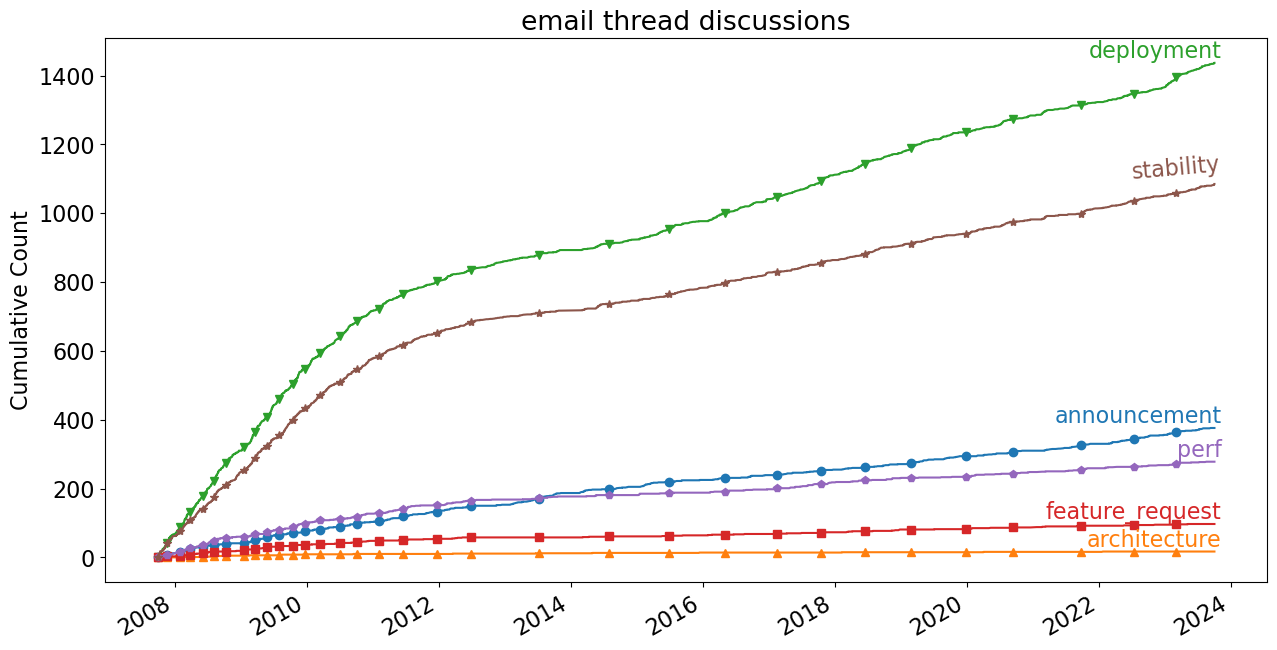

/Users/jbent/anaconda3/lib/python3.11/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname G identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


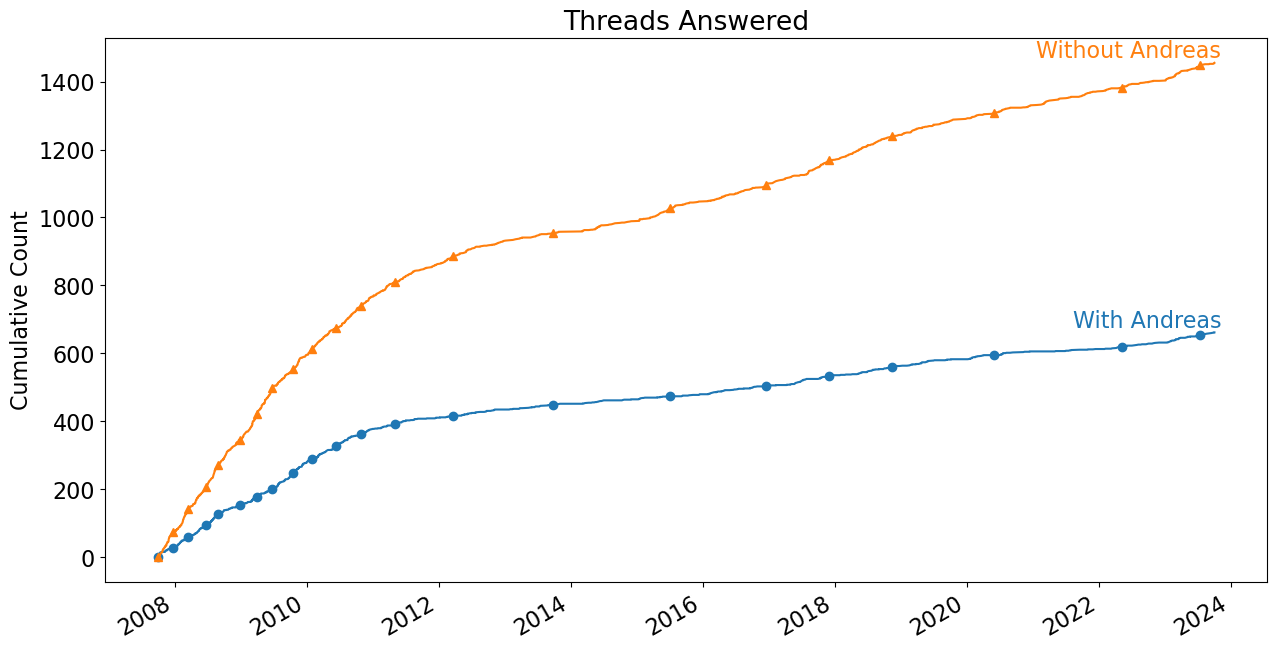

In [23]:
combinations = {
    'deployment' : ['configuration', 'deployment','installation','compilation'],
    'stability' : ['bug', 'stability','patch'],
    'perf' : ['performance']
}
plt = make_event_graph(category_data,'email thread discussions',Styles=True,leg_under=False,combinations=combinations)
plt.show()
plt = make_event_graph(answer_data, 'Threads Answered',Styles=True,leg_under=False)
plt.show()

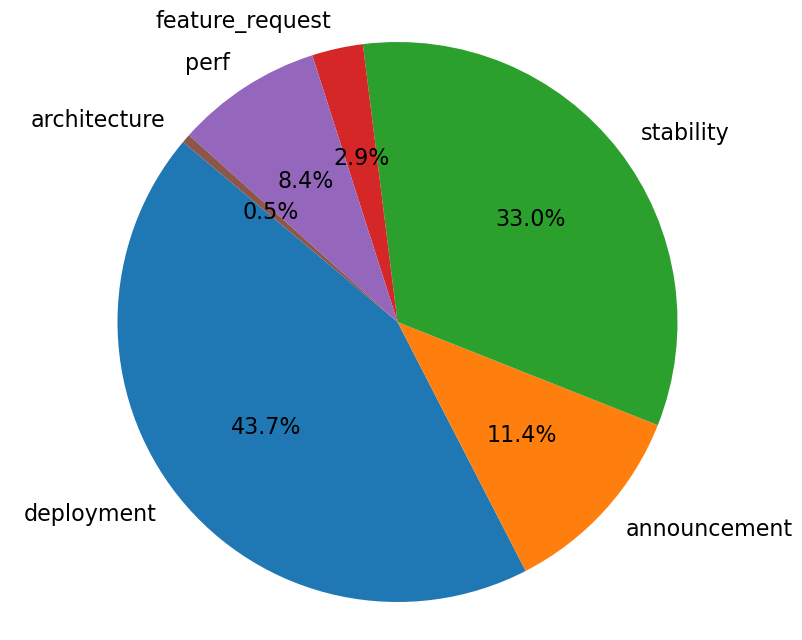

In [31]:
def create_pie_chart(events, combinations):
    # Reverse the combinations dictionary for efficient lookup
    reverse_combinations = {v: k for k, values in combinations.items() for v in values}

    # Count event types
    event_counts = {}
    for i in range(len(events['datetime'])):  # Assuming both lists are of the same length
        event_type = events['event_type'][i]
        # Consolidate event types based on combinations
        event_type = reverse_combinations.get(event_type, event_type)
        event_counts[event_type] = event_counts.get(event_type, 0) + 1

    # Convert to DataFrame
    df = pd.DataFrame(list(event_counts.items()), columns=['Event Type', 'Count'])

    # Plot Pie Chart
    plt.figure(figsize=(10, 8))
    plt.pie(df['Count'], labels=df['Event Type'], autopct='%1.1f%%', startangle=140)
    plt.axis('equal')  # Ensure the pie chart is circular.
    #plt.title('Event Type Distribution')
    plt.show()

create_pie_chart(category_data, combinations)

In [50]:
answers_by_category

{'configuration': {'count': 1274, 'answered': 991},
 'announcement': {'count': 375, 'answered': 25},
 'bug': {'count': 1025, 'answered': 622},
 'feature_request': {'count': 96, 'answered': 63},
 'installation': {'count': 114, 'answered': 80},
 'performance': {'count': 277, 'answered': 200},
 'stability': {'count': 33, 'answered': 25},
 'deployment': {'count': 9, 'answered': 8},
 'spam': {'count': 0, 'answered': 0},
 'documentation': {'count': 1, 'answered': 2},
 'compilation': {'count': 36, 'answered': 23},
 'patch': {'count': 24, 'answered': 22},
 'test': {'count': 0, 'answered': 0},
 'architecture': {'count': 16, 'answered': 12},
 'development': {'count': 2, 'answered': 2},
 'information_request': {'count': 3, 'answered': 2},
 'upgrade': {'count': 17, 'answered': 14},
 'compatibility': {'count': 9, 'answered': 8},
 'support': {'count': 5, 'answered': 4},
 'recovery': {'count': 1, 'answered': 2},
 'miscellaneous': {'count': 1, 'answered': 0},
 'information': {'count': 1, 'answered': 2

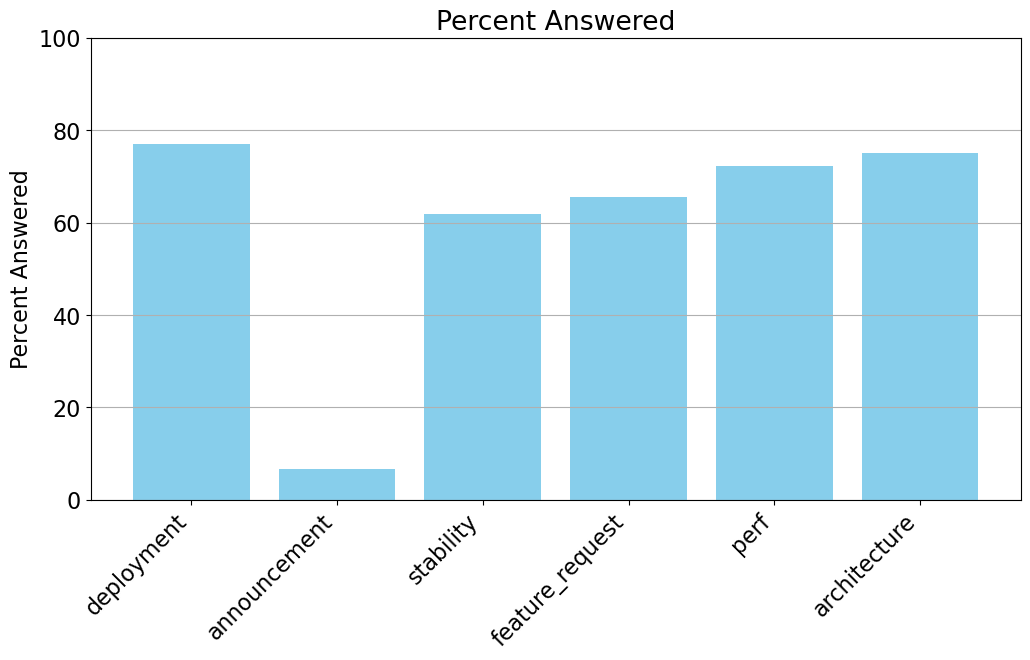

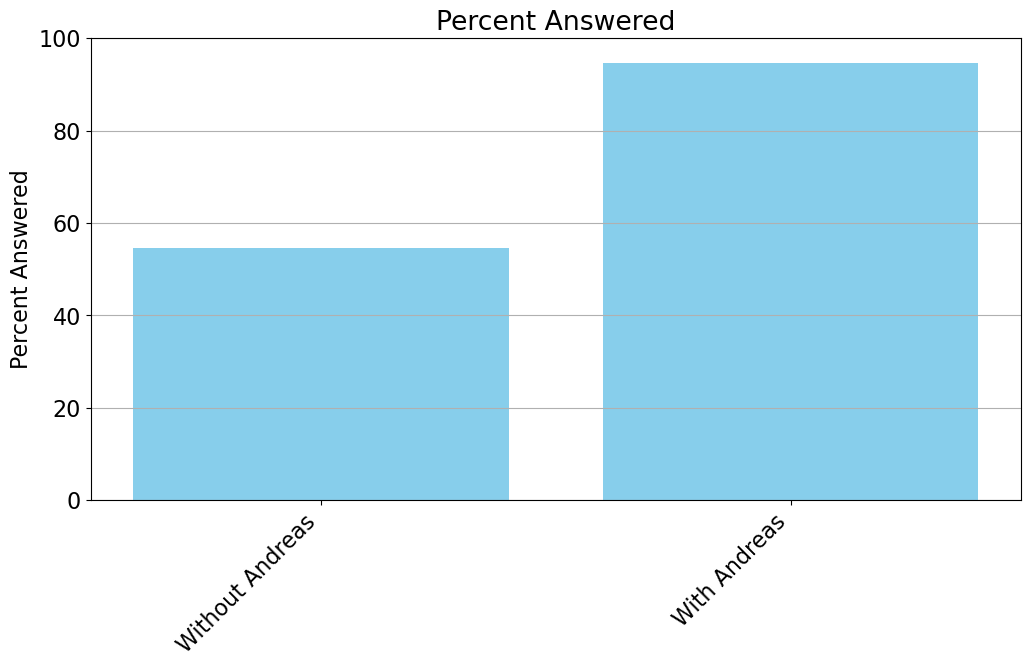

In [63]:
def create_bar_graph(events, combinations):
    # Consolidate event types
    consolidated_events = {}
    for event, data in events.items():
        if data['count'] < 5:
            continue  # Skip events with count less than 5

        # Find the consolidated category for the event
        consolidated_category = next((k for k, v in combinations.items() if event in v), event)

        # Aggregate data
        if consolidated_category not in consolidated_events:
            consolidated_events[consolidated_category] = {'count': 0, 'answered': 0}
        consolidated_events[consolidated_category]['count'] += data['count']
        consolidated_events[consolidated_category]['answered'] += data['answered']

    # Calculate percent answered
    categories = []
    percent_answered = []
    for category, data in consolidated_events.items():
        categories.append(category)
        percent = (data['answered'] / data['count']) * 100 if data['count'] > 0 else 0
        percent_answered.append(percent)

    # Convert to DataFrame
    df = pd.DataFrame({'Category': categories, 'Percent Answered': percent_answered})

    # Plot Bar Graph
    plt.figure(figsize=(12, 6))
    plt.bar(df['Category'], df['Percent Answered'], color='skyblue')
    #plt.xlabel('Event Type')
    plt.ylabel('Percent Answered')
    plt.xticks(rotation=45, ha='right')
    plt.title('Percent Answered')
    plt.ylim(0, 100)
    plt.grid(axis='y')
    plt.show()

create_bar_graph(answers_by_category, combinations)
create_bar_graph(answers_by_andreas, {})

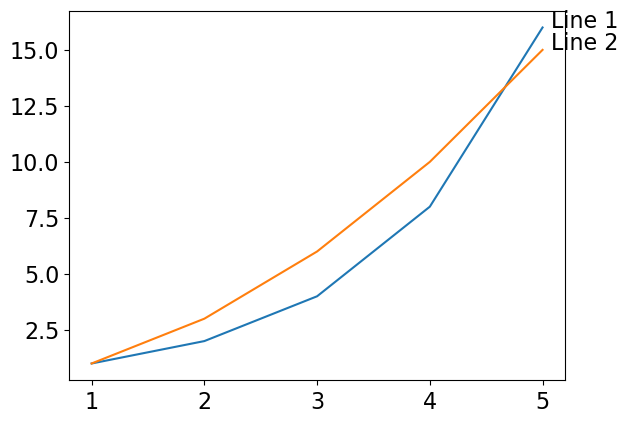

In [24]:
# Example data
x = [1, 2, 3, 4, 5]
y1 = [1, 2, 4, 8, 16]
y2 = [1, 3, 6, 10, 15]

# Create a figure and an axes
fig, ax = plt.subplots()

# Plotting the lines
line1, = ax.plot(x, y1, label='Line 1')
line2, = ax.plot(x, y2, label='Line 2')

# Annotating the end of each line
ax.annotate(line1.get_label(), xy=(x[-1], y1[-1]), xytext=(6,0), textcoords='offset points')
ax.annotate(line2.get_label(), xy=(x[-1], y2[-1]), xytext=(6,0), textcoords='offset points')

plt.show()